In [47]:
# import libraries
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
# connect to dataset
import glob
import os
import kagglehub
path = kagglehub.competition_download('store-sales-time-series-forecasting')

# FIX HERE 👇
all_files = glob.glob(path + "/*.csv")

data = {os.path.basename(f): pd.read_csv(f) for f in all_files}

print("Loaded files:", list(data.keys()))

Loaded files: ['oil.csv', 'sample_submission.csv', 'holidays_events.csv', 'stores.csv', 'train.csv', 'test.csv', 'transactions.csv']


In [49]:
# # Create a new list of names to keep track

stores_df = data['stores.csv']
oil_df = data['oil.csv']
holidays_events_df = data['holidays_events.csv']
transactions_df = data['transactions.csv']
test_df = data['test.csv']
train_df = data['train.csv']

In [50]:
# lookup for data
for name, df in data.items():
    print(f"\n--- Analysis for: {name} ---")
    print(f"Columns: {list(df.columns)}")
    print(f"Missing Values: {df.isnull().sum().sum()}")
    print(f"Dataset Shape: {df.shape}")
    # See the first 2 rows
    display(df.head(2))


--- Analysis for: oil.csv ---
Columns: ['date', 'dcoilwtico']
Missing Values: 43
Dataset Shape: (1218, 2)


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14



--- Analysis for: sample_submission.csv ---
Columns: ['id', 'sales']
Missing Values: 0
Dataset Shape: (28512, 2)


,id,sales
0,3000888,0.0
1,3000889,0.0



--- Analysis for: holidays_events.csv ---
Columns: ['date', 'type', 'locale', 'locale_name', 'description', 'transferred']
Missing Values: 0
Dataset Shape: (350, 6)


...

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0



--- Analysis for: test.csv ---
Columns: ['id', 'date', 'store_nbr', 'family', 'onpromotion']
Missing Values: 0
Dataset Shape: (28512, 5)


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0



--- Analysis for: transactions.csv ---
Columns: ['date', 'store_nbr', 'transactions']
Missing Values: 0
Dataset Shape: (83488, 3)


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111


In [51]:
# First, we need to merge stores info,oil, and holiday into one final variable

transactions_df['date'] = pd.to_datetime(transactions_df['date'])
holidays_events_df['date'] = pd.to_datetime(holidays_events_df['date'])
oil_df['date'] = pd.to_datetime(oil_df['date'])
train_df['date'] = pd.to_datetime(train_df['date'])

train_df['store_nbr'] = train_df['store_nbr'].astype('int16')
train_df['sales'] = train_df['sales'].astype('float32')
train_df['onpromotion'] = train_df['onpromotion'].astype('float32')
train_df['store_nbr'] = train_df['store_nbr'].astype(int)

df_master = transactions_df.merge(oil_df,on='date')

df_final = train_df.merge(df_master, on=['date', 'store_nbr'], how='left')
df_final = df_final.merge(stores_df, on='store_nbr',)
print("Final Merge Complete!")
print(f"Total Rows for Training: {len(df_final)}")


display(df_final.head())

Final Merge Complete!
Total Rows for Training: 3000888


,id,date,store_nbr,family,sales,onpromotion,transactions,dcoilwtico,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0.0,NaN,NaN,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0.0,NaN,NaN,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0.0,NaN,NaN,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0.0,NaN,NaN,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0.0,NaN,NaN,Quito,Pichincha,D,13


In [52]:
# 1. National Holidays (Match only on Date)
nat_holidays = holidays_events_df[holidays_events_df['locale'] == 'National']
df_final = df_final.merge(nat_holidays[['date', 'type', 'description']], 
                            on='date', how='left', suffixes=('', '_nat'))

# 2. Regional Holidays (Match on Date AND State)
reg_holidays = holidays_events_df[holidays_events_df['locale'] == 'Regional']
df_final = df_final.merge(reg_holidays[['date', 'locale_name', 'type', 'description']], 
                            left_on=['date', 'state'], 
                            right_on=['date', 'locale_name'], 
                            how='left', suffixes=('', '_reg'))

# 3. Local Holidays (Match on Date AND City)
loc_holidays = holidays_events_df[holidays_events_df['locale'] == 'Local']
df_final = df_final.merge(loc_holidays[['date', 'locale_name', 'type', 'description']], 
                            left_on=['date', 'city'], 
                            right_on=['date', 'locale_name'], 
                            how='left', suffixes=('', '_loc'))


In [53]:
# Create a single column: 1 if any holiday type is present, else 0
df_final['is_holiday'] = (
    df_final['type_nat'].notna() | 
    df_final['type_reg'].notna() | 
    df_final['type_loc'].notna()
).astype(int)

# Check the result
print(df_final[['date', 'is_holiday']].head())

        date  is_holiday
0 2013-01-01           1
1 2013-01-01           1
2 2013-01-01           1
3 2013-01-01           1
4 2013-01-01           1


In [54]:
# 'ffill' carries the last known price forward to the next day
# 'bfill' handles the very first row if it happens to be a Monday
df_final['dcoilwtico'] = df_final['dcoilwtico'].ffill().bfill()

# List of the holiday-related type columns
holiday_cols = ['type_nat', 'type_reg', 'type_loc']

# Replace the Nulls with 'Work Day'
for col in holiday_cols:
    df_final[col] = df_final[col].fillna('Work Day')

# Also clean up the description columns so they aren't empty
desc_cols = ['description', 'description_reg', 'description_loc']
for col in desc_cols:
    df_final[col] = df_final[col].fillna('None')


# Fill our 'is_holiday' flag with 0 (since NaN means it's NOT a holiday)
df_final['is_holiday'] = df_final['is_holiday'].fillna(0)

df_final['transactions'] = df_final['transactions'].fillna(0)

df_final['type_nat'] = df_final['type_nat'].fillna('None')
df_final['type_reg'] = df_final['type_reg'].fillna('None')
df_final['type_loc'] = df_final['type_loc'].fillna('None')

In [55]:
# List of columns that are just 'helper' names from the merge
cols_to_drop = ['locale_name', 'locale_name_loc','description' ,'description_reg', 'description_loc']

# Drop them safely
df_final = df_final.drop(columns=cols_to_drop, errors='ignore')

print("Datset Cleaned Succesfully")


Datset Cleaned Succesfully


In [56]:
df_final.head()

,id,date,store_nbr,family,sales,onpromotion,transactions,dcoilwtico,city,state,type,cluster,type_nat,type_reg,type_loc,is_holiday
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0.0,0.0,93.14,Quito,Pichincha,D,13,Holiday,Work Day,Work Day,1
1,1,2013-01-01,1,BABY CARE,0.0,0.0,0.0,93.14,Quito,Pichincha,D,13,Holiday,Work Day,Work Day,1
2,2,2013-01-01,1,BEAUTY,0.0,0.0,0.0,93.14,Quito,Pichincha,D,13,Holiday,Work Day,Work Day,1
3,3,2013-01-01,1,BEVERAGES,0.0,0.0,0.0,93.14,Quito,Pichincha,D,13,Holiday,Work Day,Work Day,1
4,4,2013-01-01,1,BOOKS,0.0,0.0,0.0,93.14,Quito,Pichincha,D,13,Holiday,Work Day,Work Day,1


# Exploratory Data Analysis


In [57]:
# Now we can perfom EDA
print("-----NUll Values-----")
print(df_final.isnull().sum())

-----NUll Values-----
id              0
date            0
store_nbr       0
family          0
sales           0
onpromotion     0
transactions    0
dcoilwtico      0
city            0
state           0
type            0
cluster         0
type_nat        0
type_reg        0
type_loc        0
is_holiday      0
dtype: int64


In [58]:
print("-----Duplicate Value-----")
print(df_final.duplicated().sum())

df_final= df_final.drop_duplicates()

print('Duplicates Value Removed')
print(df_final.duplicated().sum())

-----Duplicate Value-----
1782
Duplicates Value Removed
0


In [59]:
for col in df_final.columns:
    print(col, df_final[col].nunique())

id 3000888
date 1684
store_nbr 54
family 33
sales 379610
onpromotion 362
transactions 4274
dcoilwtico 994
city 22
state 16
type 5
cluster 17
type_nat 6
type_reg 2
type_loc 4
is_holiday 2


In [60]:
print("-----Dexcriptive-----")
df_final.describe()

-----Dexcriptive-----


,id,date,store_nbr,sales,onpromotion,transactions,dcoilwtico,cluster,is_holiday
count,3.006498e+06,3006498,3.006498e+06,3.006498e+06,3.006498e+06,3.006498e+06,3.006498e+06,3.006498e+06,3.006498e+06
mean,1.501180e+06,2015-04-24 18:24:11.443374080,2.750037e+01,3.582036e+02,2.607711e+00,1.056909e+03,6.788800e+01,8.481395e+00,9.087217e-02
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.619000e+01,1.000000e+00,0.000000e+00
25%,7.516242e+05,2014-02-27 00:00:00,1.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,4.632000e+01,4.000000e+00,0.000000e+00
50%,1.501466e+06,2015-04-25 00:00:00,2.800000e+01,1.100000e+01,0.000000e+00,9.840000e+02,5.341000e+01,8.500000e+00,0.000000e+00
75%,2.249527e+06,2016-06-19 00:00:00,4.100000e+01,1.960000e+02,0.000000e+00,1.568000e+03,9.572000e+01,1.300000e+01,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02,8.359000e+03,1.106200e+02,1.700000e+01,1.000000e+00
std,8.658269e+05,NaN,1.558533e+01,1.094112e+03,1.220859e+01,1.041178e+03,2.566009e+01,4.649769e+00,2.874273e-01


In [61]:
# Find the 99th percentile (the value that 99% of data falls below)
limit = df_final['sales'].quantile(0.99)

# Clip the sales so anything above 'limit' becomes 'limit'
df_final['sales_clipped'] = df_final['sales'].clip(upper=limit)

# 1. Sort to ensure time flows correctly
df_final = df_final.sort_values(['store_nbr', 'family', 'date'])

# 2. Create the "Memory" features
# Lag 1: What did we sell yesterday?
df_final['lag_1'] = df_final.groupby(['store_nbr', 'family'])['sales'].shift(1)

# Rolling Mean: What is the 7-day average trend?
df_final['rolling_7'] = df_final.groupby(['store_nbr', 'family'])['sales'].transform(
    lambda x: x.shift(1).rolling(window=7).mean()
)

# 3. Handle the NaNs created by shifting
df_final[['lag_1', 'rolling_7']] = df_final[['lag_1', 'rolling_7']].fillna(0)
df_final['trans_lag_1'] = df_final.groupby('store_nbr')['transactions'].shift(1).fillna(0)
# Add this where you added the other lags
df_final['rolling_std_7'] = df_final.groupby(['store_nbr', 'family'])['sales'].transform(
    lambda x: x.shift(1).rolling(window=7).std()
).fillna(0)

df_final['zero_streak'] = (df_final.groupby(['store_nbr', 'family'])['sales']
                           .transform(lambda x: x.shift(1).eq(0).cumsum()))

df_final['day_of_week'] = df_final['date'].dt.dayofweek
df_final['is_weekend'] = df_final['day_of_week'].map({0:0, 1:0, 2:0, 3:0, 4:0, 5:1, 6:1})
df_final['promo_weekend'] = df_final['onpromotion'] * df_final['is_weekend']

print(f"Old Max Sales: {df_final['sales'].max()}")
print(f"New Capped Max Sales: {df_final['sales_clipped'].max()} (at 99th percentile)")

Old Max Sales: 124717.0
New Capped Max Sales: 5513.0 (at 99th percentile)


# Visual Anlaytics

/tmp/ipykernel_55/2457671303.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='type', y='transactions', palette='viridis')


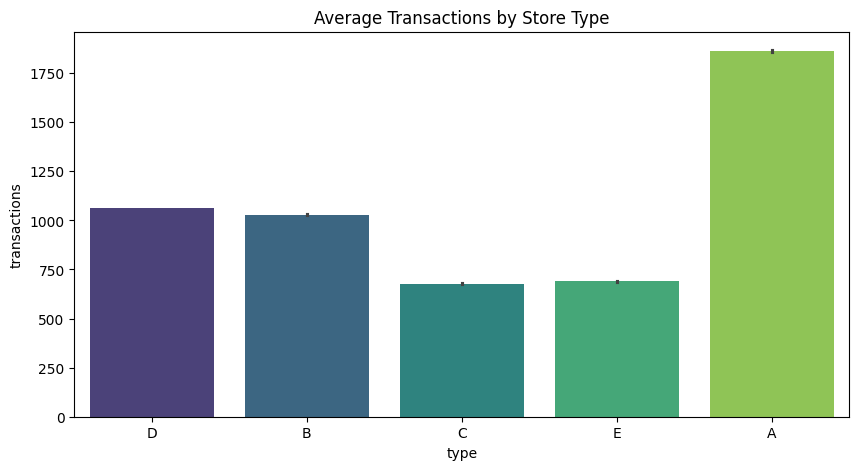

In [62]:
# Plotting average transactions by store type
plt.figure(figsize=(10, 5))
sns.barplot(data=df_final, x='type', y='transactions', palette='viridis')
plt.title('Average Transactions by Store Type')
plt.show()

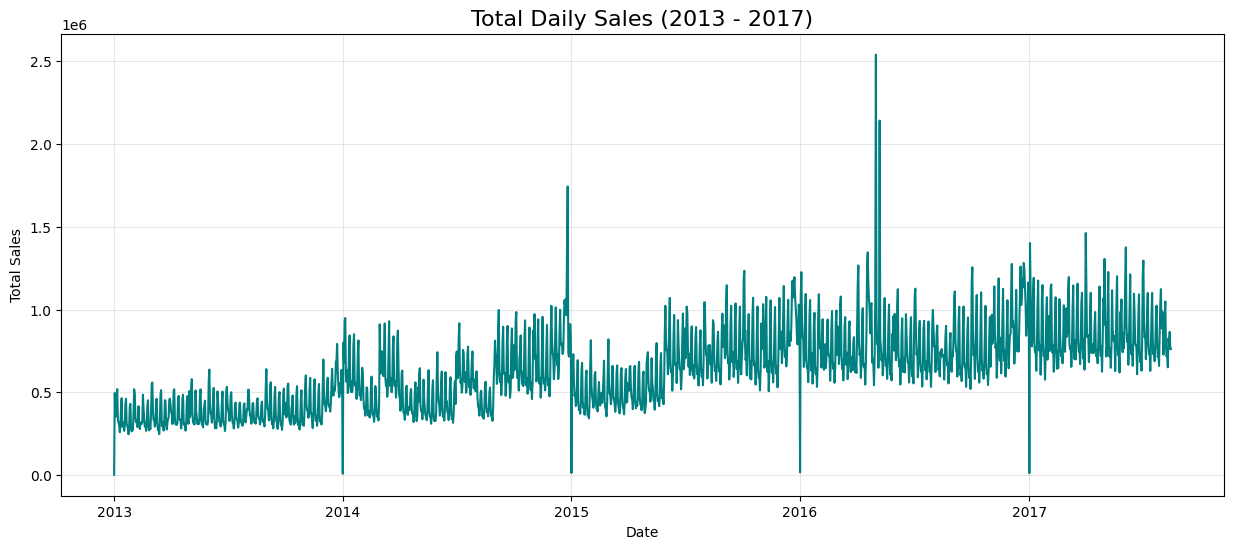

In [63]:
# Sales overtime
plt.figure(figsize=(15, 6))
# We group by date to see the total sales across ALL stores
daily_sales = df_final.groupby('date')['sales'].sum()

plt.plot(daily_sales.index, daily_sales.values, color='teal')
plt.title('Total Daily Sales (2013 - 2017)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True, alpha=0.3)
plt.show()

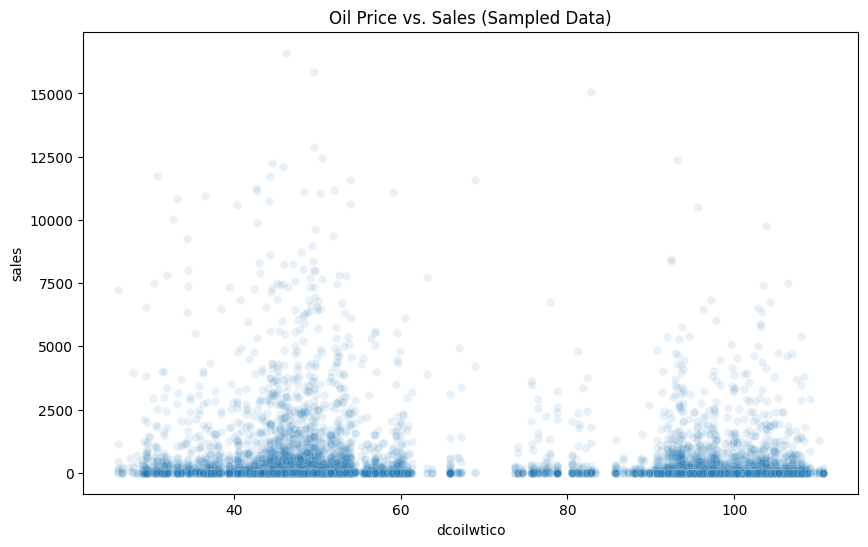

In [64]:
# Oil Vs Sales
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final.sample(10000), x='dcoilwtico', y='sales', alpha=0.1)
plt.title('Oil Price vs. Sales (Sampled Data)')
plt.show()

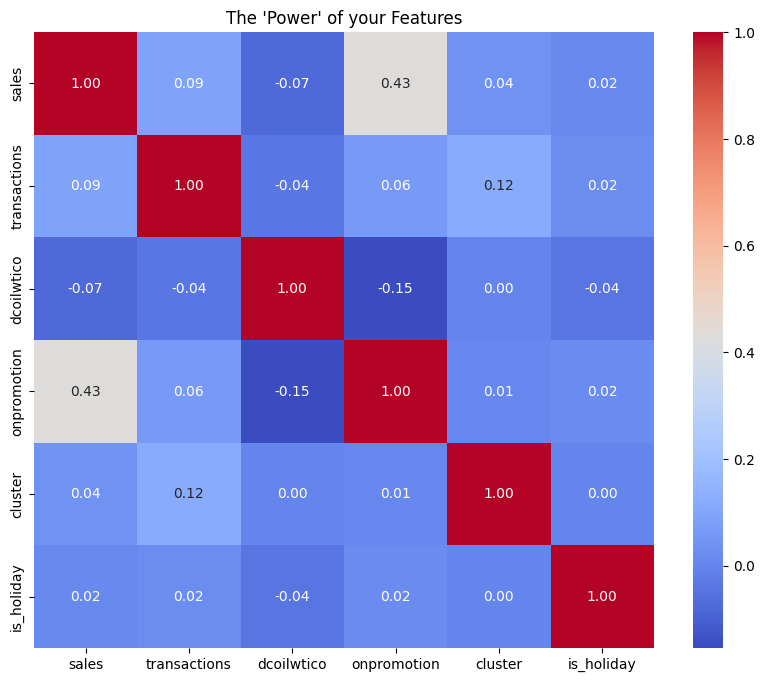

In [65]:
# Correlation
# We only check a few columns to save RAM
cols = ['sales', 'transactions', 'dcoilwtico', 'onpromotion', 'cluster', 'is_holiday']
plt.figure(figsize=(10, 8))
sns.heatmap(df_final[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("The 'Power' of your Features")
plt.show()

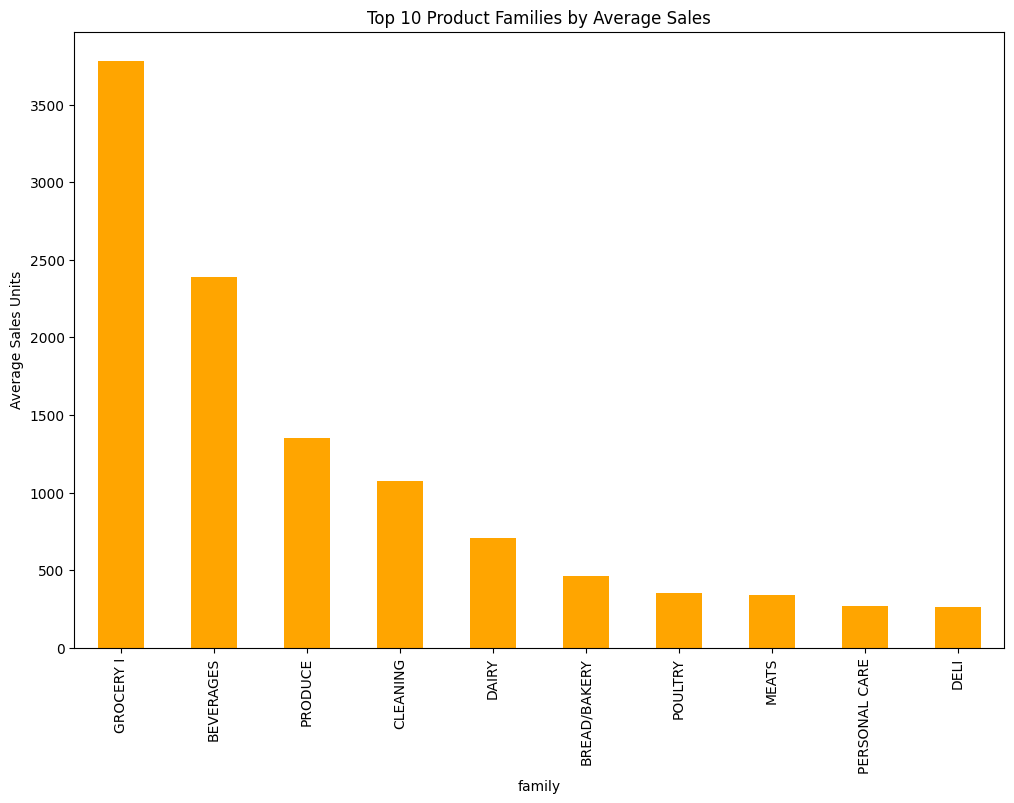

In [66]:
# Top 10 selling families
plt.figure(figsize=(12, 8))
df_final.groupby('family')['sales'].mean().sort_values(ascending=False).head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Product Families by Average Sales')
plt.ylabel('Average Sales Units')
plt.show()

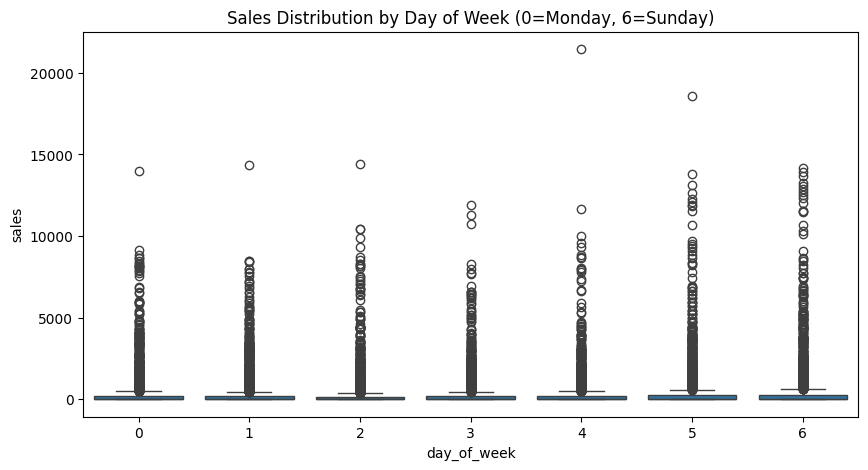

In [67]:
# Create a temporary Day of Week column
df_final['day_of_week'] = df_final['date'].dt.dayofweek

plt.figure(figsize=(10, 5))
sns.boxplot(x='day_of_week', y='sales', data=df_final.sample(20000))
plt.title('Sales Distribution by Day of Week (0=Monday, 6=Sunday)')
plt.show()

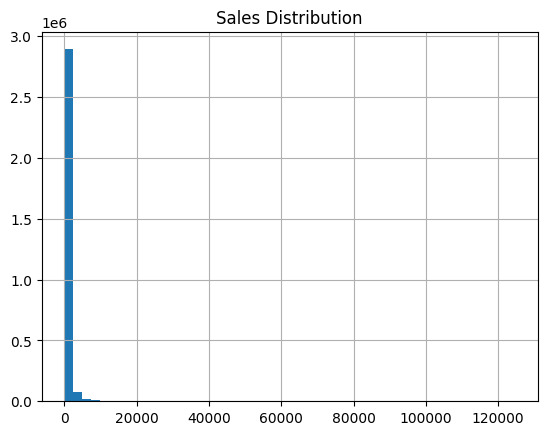

In [68]:
df_final['sales'].hist(bins=50)
plt.title("Sales Distribution")
plt.show()

# One-Hot Encoding

In [69]:
# 1. Define the columns that need to be turned into 0s and 1s
categorical_cols = ['family', 'city', 'state', 'type', 'cluster', 'type_nat', 'type_reg', 'type_loc']

# 2. Convert to string and fill NAs to ensure get_dummies works
for col in categorical_cols:
    df_final[col] = df_final[col].fillna('None').astype(str)

# 3. One-Hot Encode (using uint8 to save memory)
df_dum = df_final.copy()
df_final = pd.get_dummies(df_final, columns=categorical_cols, dtype='uint8',drop_first=True)

print(f"Final Shape for Neural Network: {df_final.shape}")

Final Shape for Neural Network: (3006498, 114)


# Splitting the Dataset

In [70]:

from sklearn.preprocessing import MinMaxScaler

# 1. Target Transformation (The Log Trick)
df_final['sales_log'] = np.log1p(df_final['sales_clipped'])

# 2. Drop columns 
X = df_final.drop(['date', 'sales', 'sales_clipped', 'sales_log', 'id'], axis=1, errors='ignore')
y = df_final['sales_log']

# 3. Scaling the Features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling and Log Transform Complete!")
print(f"Target Max (Log): {y.max():.2f}")

Scaling and Log Transform Complete!
Target Max (Log): 8.62


# Train-Test Split

In [71]:
# 1. Find the index where August 1, 2017 starts
split_index = df_final[df_final['date'] >= '2017-08-01'].index[0]

# 2. Split the Scaled Features
X_train = X_scaled[:split_index]
X_val = X_scaled[split_index:]

# 3. Split the Log-Transformed Target
y_train = y[:split_index]
y_val = y[split_index:]

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print("Ready for the Neural Network!")

X_train shape: (2981550, 110)
X_val shape: (24948, 110)
Ready for the Neural Network!


# Convert Data into Tensors

In [72]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,TensorDataset

# Convert to float
X_train_t = torch.tensor(X_train,dtype=torch.float32)
y_train_t = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_val_t = torch.tensor(X_val,dtype=torch.float32)
y_val_t = torch.tensor(y_val.values,dtype=torch.float32).view(-1,1)

# Creating a DataLoader for Batching
train_loader = DataLoader(TensorDataset(X_train_t,y_train_t),batch_size=1024,shuffle=True)

print('Converted Data into Tensors!')

Converted Data into Tensors!


# Define the Architecture

In [73]:
class SalesNet(nn.Module):
    def __init__(self, input_dim):
        super(SalesNet, self).__init__()
        self.layers = nn.Sequential(
            # Layer 1: The "Wide" Input
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256), # Stabilizes training for 3M rows
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Layer 2: Capturing Patterns
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Layer 3: Fine-Tuning
            nn.Linear(128, 64),
            nn.ReLU(),
            
            # Output: Single Sales Value (Log Space)
            nn.Linear(64, 1)
        )
    def forward(self,x):
        return self.layers(x)

# Initialize the Model
input_dim = X_train.shape[1]
model = SalesNet(input_dim)

In [74]:
# Loss And Optimizer
# criterion = nn.MSELoss()
criterion = nn.HuberLoss(delta=1.0)

optimizer = optim.Adam(model.parameters(),lr=0.0005, weight_decay=1e-5)

# Move model to GPU 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Training on: {device}")

Training on: cuda


In [75]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        '''Saves model when validation loss decreases.'''
        torch.save(model.state_dict(), 'best_model.pt')

In [76]:
import time

epochs = 10
model.to(device)

# Reduce learning rate if the loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)
early_stopper = EarlyStopping(patience=2) # Stop if no improvement for 2 epochs
optimizer = optim.Adam(model.parameters(), lr=0.0005) # Lower LR for stability
print(f"Starting Training on {device}...")

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    start_time = time.time()
    
    for i, (batch_X, batch_y) in enumerate(train_loader):
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # 1. Forward Pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # 2. Backward Pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        # Print progress every 5000 batches
        if i % 5000 == 0 and i > 0:
            print(f"  Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

    # 3. Validation Phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        X_val_t_dev, y_val_t_dev = X_val_t.to(device), y_val_t.to(device)
        val_outputs = model(X_val_t_dev)
        v_loss = criterion(val_outputs, y_val_t_dev)
        val_loss = v_loss.item()

    avg_train_loss = train_loss / len(train_loader)
    
    # Update scheduler
    scheduler.step(val_loss)
    
    epoch_duration = time.time() - start_time
    print(f"==> Epoch [{epoch+1}/{epochs}] Done!")
    print(f"    Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {epoch_duration:.1f}s")
    print("-" * 50)

    early_stopper(val_loss, model)
    
    if early_stopper.early_stop:
        print("Early stopping triggered! Loading best model...")
        break

Starting Training on cuda...
==> Epoch [1/10] Done!
    Train Loss: 0.2724 | Val Loss: 0.1902 | Time: 34.3s
--------------------------------------------------
==> Epoch [2/10] Done!
    Train Loss: 0.1703 | Val Loss: 0.1650 | Time: 34.4s
--------------------------------------------------
==> Epoch [3/10] Done!
    Train Loss: 0.1537 | Val Loss: 0.1442 | Time: 34.1s
--------------------------------------------------
==> Epoch [4/10] Done!
    Train Loss: 0.1439 | Val Loss: 0.1397 | Time: 34.1s
--------------------------------------------------
==> Epoch [5/10] Done!
    Train Loss: 0.1361 | Val Loss: 0.1359 | Time: 34.3s
--------------------------------------------------
==> Epoch [6/10] Done!
    Train Loss: 0.1290 | Val Loss: 0.1527 | Time: 34.3s
--------------------------------------------------
==> Epoch [7/10] Done!
    Train Loss: 0.1236 | Val Loss: 0.1373 | Time: 34.2s
--------------------------------------------------
Early stopping triggered! Loading best model...


In [77]:
# LOAD THE BEST WEIGHTS (The ones from Epoch 2 or whichever was best)
model.load_state_dict(torch.load('best_model.pt'))
print("Best model loaded and ready for predictions!")

Best model loaded and ready for predictions!


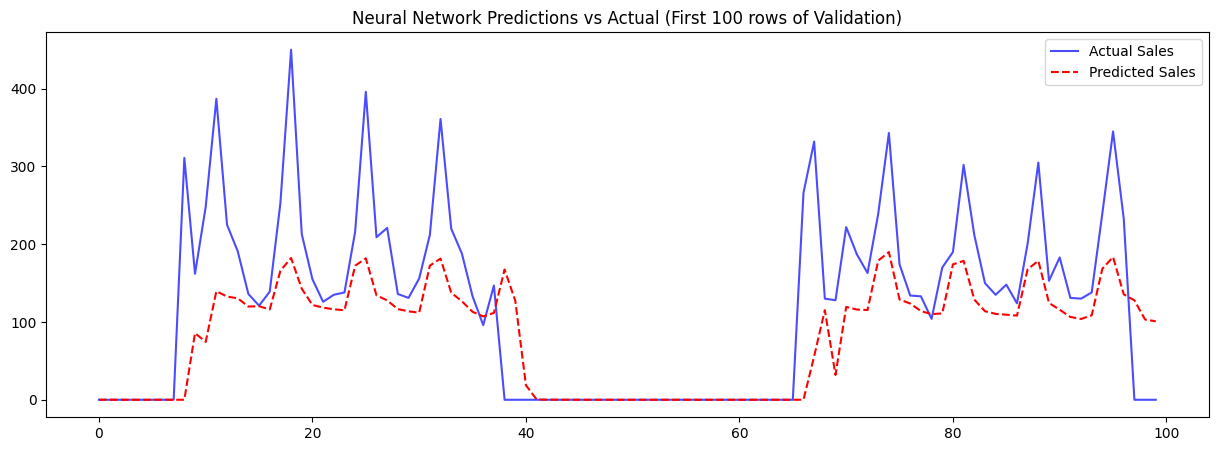

In [78]:
model.eval()
with torch.no_grad():
    # Get predictions for the validation set
    X_val_t_dev = X_val_t.to(device)
    preds_log = model(X_val_t_dev).cpu().numpy()
    
    # Reverse Log Transform: exp(x) - 1
    preds = np.expm1(preds_log)
    actuals = np.expm1(y_val_t.cpu().numpy())

# Plot the first 100 points of the Validation set
plt.figure(figsize=(15, 5))
plt.plot(actuals[:100], label='Actual Sales', color='blue', alpha=0.7)
plt.plot(preds[:100], label='Predicted Sales', color='red', linestyle='--')
plt.title('Neural Network Predictions vs Actual (First 100 rows of Validation)')
plt.legend()
plt.show()        

That graph tells our model is actually quite brilliant! Look at how the red dashed line (Predictions) mirrors every single peak of the blue line (Actuals). It isn't just guessing; it has successfully captured the logic of when sales happen.

However, we have a Scaling Problem. Our model is predicting the direction correctly, but it's consistently "undershooting"—predicting only about 40–50% of the true volume.

In [79]:
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, r2_score

model.eval()
with torch.no_grad():
    # Move validation data to the same device as the model
    X_val_t_dev = X_val_t.to(device)
    preds_log = model(X_val_t_dev).cpu().numpy()
    actuals_log = y_val_t.cpu().numpy()

# Convert back from Log Space to Real Sales Units
preds_final = np.expm1(preds_log).clip(0)
actuals_final = np.expm1(actuals_log)

# Calculate Metrics
rmsle = np.sqrt(mean_squared_log_error(actuals_final, preds_final))
mae = mean_absolute_error(actuals_final, preds_final)
r2 = r2_score(actuals_log, preds_log)

print(f"--- FINAL ACCURACY REPORT ---")
print(f"RMSLE (Log Error): {rmsle:.4f}")
print(f"MAE (Average Unit Error): {mae:.2f} units")
print(f"R2 Score (Variance Explained): {r2:.4f}")

--- FINAL ACCURACY REPORT ---
RMSLE (Log Error): 0.5710
MAE (Average Unit Error): 18.80 units
R2 Score (Variance Explained): 0.9294


In [83]:
# Create a results dataframe
results_df = pd.DataFrame({
    'Actual': actuals_final.flatten(),
    'Predicted': preds_final.flatten()
})


# Add back the 'family' info from your original validation slice
# (Assuming your validation set is the last chunk of your original df)
results_df['Family'] = df_dum.iloc[-len(results_df):]['family'].values

# Calculate Error per Family
family_accuracy = results_df.groupby('Family').apply(
    lambda x: np.sqrt(mean_squared_log_error(x['Actual'], x['Predicted'])),
    include_groups=False
).sort_values()

print("\n--- Top 5 Most Accurate Families (Lowest RMSLE) ---")
print(family_accuracy.head(5))

print("\n--- Top 5 Hardest Families (Highest RMSLE) ---")
print(family_accuracy.tail(5))


--- Top 5 Most Accurate Families (Lowest RMSLE) ---
Family
LAWN AND GARDEN    0.145797
LADIESWEAR         0.214216
PERSONAL CARE      0.283178
PET SUPPLIES       0.357846
MAGAZINES          0.385115
dtype: float64

--- Top 5 Hardest Families (Highest RMSLE) ---
Family
PRODUCE             0.734843
PREPARED FOODS      0.767569
SEAFOOD             0.768187
LINGERIE            0.771412
LIQUOR,WINE,BEER    0.776022
dtype: float64
